In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

df = pd.read_csv("processed/cleaned_global_edu_policy.csv")

metadata_cols = ["iso3", "country", "region", "wb_econ"]
df_meta = df[metadata_cols]

features = [
    "gdp_pc_ppp", "urban_pct", "youth_dependency_ratio", "lfp_gender_gap",
    "finbar_prim", "compend_prim", "disc_sex_prim", "incl_edu"
]
X = df[features]

# Refit the same PCA pipeline used in 02a to ensure identical input space
N_COMPONENTS = 4
preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=N_COMPONENTS, random_state=42))
])
X_pca = preprocessing_pipeline.fit_transform(X)

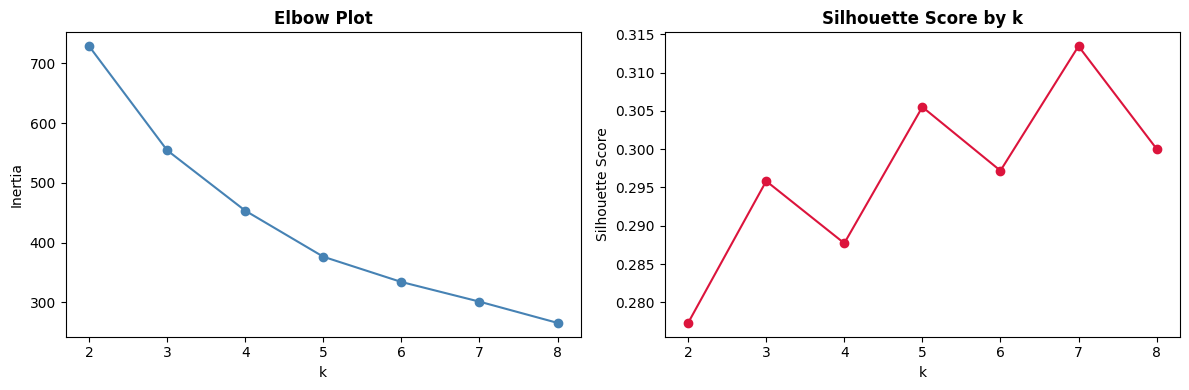

Inertia:     {2: 728.8, 3: 554.5, 4: 453.5, 5: 376.5, 6: 334.2, 7: 301.3, 8: 265.8}
Silhouette:  {2: np.float64(0.277), 3: np.float64(0.296), 4: np.float64(0.288), 5: np.float64(0.306), 6: np.float64(0.297), 7: np.float64(0.313), 8: np.float64(0.3)}


In [2]:
# Compare different cluster numbers (k from 2 to 8)
# We track inertia (compactness) and silhouette scores (separation) to find the sweet spot
# Plot and save both metrics to help pick the best k
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, marker="o", color="steelblue")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_xticks(list(k_range))
ax1.set_title("Elbow Plot", fontweight="bold")

ax2.plot(k_range, silhouettes, marker="o", color="crimson")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(list(k_range))
ax2.set_title("Silhouette Score by k", fontweight="bold")

plt.tight_layout()
plt.savefig("processed/kmeans_elbow_silhouette.png", dpi=300)
plt.show()

print("Inertia:    ", {k: round(v, 1) for k, v in zip(k_range, inertias)})
print("Silhouette: ", {k: round(v, 3) for k, v in zip(k_range, silhouettes)})

In [3]:
# Even though k=7 has the best silhouette score, we use k=4 here
# This matches our GMM model so we can easily compare the two algorithms later
# We accept the slight drop in silhouette score for better comparison
# Save the PCA coordinates and cluster labels back to our dataset.
K = 4

km = KMeans(n_clusters=K, init="k-means++", n_init=20, random_state=42)
km_labels = km.fit_predict(X_pca)

df_results_km = df_meta.copy()
df_results_km["PC1"] = X_pca[:, 0]
df_results_km["PC2"] = X_pca[:, 1]
df_results_km["PC3"] = X_pca[:, 2]
df_results_km["PC4"] = X_pca[:, 3]
df_results_km["km_cluster"] = km_labels.astype(str)

print("--- K-Means Cluster Distribution (k=4) ---")
print(df_results_km["km_cluster"].value_counts().sort_index())
print(f"\nInertia: {km.inertia_:.1f}")

--- K-Means Cluster Distribution (k=4) ---
km_cluster
0     7
1    72
2    38
3    48
Name: count, dtype: int64

Inertia: 453.5


In [4]:
df_results_km_inspect = df_results_km.copy()
df_results_km_inspect = df_results_km_inspect.join(X)

small_cluster = df_results_km["km_cluster"].value_counts().idxmin()
small = df_results_km_inspect[df_results_km_inspect["km_cluster"] == small_cluster]

print(f"Small cluster label: {small_cluster}")
print(f"\nCountries:")
print(small[["country", "region", "wb_econ"]].to_string(index=False))
print(f"\nFeature profile:")
print(small[features].round(2).T)

Small cluster label: 0

Countries:
         country              region  wb_econ
          Bhutan          South Asia      2.0
        Botswana  Sub-Saharan Africa      2.0
         Burundi  Sub-Saharan Africa      1.0
Papua New Guinea East Asia & Pacific      2.0
 Solomon Islands East Asia & Pacific      2.0
    South Africa  Sub-Saharan Africa      2.0
         Vanuatu East Asia & Pacific      2.0

Feature profile:
                             17        20       25       114      133  \
gdp_pc_ppp              15063.81  19976.83  1104.78  4419.62  2496.23   
urban_pct                  40.94     66.59    22.32    14.74    29.35   
youth_dependency_ratio      0.31      0.51     0.89     0.54     0.64   
lfp_gender_gap             19.60      9.43    -2.33     2.62     3.89   
finbar_prim                 2.00      3.00     2.00     2.00     0.00   
compend_prim                0.00      0.00     2.00     0.00     0.00   
disc_sex_prim               3.00      3.00     3.00     1.00     1.0

In [5]:
# K-Means group 0 found the exact same 7-country legislative gap cluster as GMM
# Even though the two algorithms use completely different math, they agree here
# This cross-method agreement proves this cluster is a real, solid pattern in our data
# Calculate and display the average feature values for each K-Means cluster.

df_analysis_km = X.copy()
df_analysis_km["km_cluster"] = km_labels

cluster_profiles_km = df_analysis_km.groupby("km_cluster").mean()

print("--- Mean Feature Profiles by K-Means Cluster ---")
print(cluster_profiles_km.round(2).T)

--- Mean Feature Profiles by K-Means Cluster ---
km_cluster                    0         1         2        3
gdp_pc_ppp              8751.85  51247.75  13117.42  8046.40
urban_pct                 37.09     76.27     51.14    47.38
youth_dependency_ratio     0.57      0.27      0.48     0.65
lfp_gender_gap             8.02     15.75     35.00    13.89
finbar_prim                1.57      2.90      2.92     2.94
compend_prim               0.71      3.00      3.00     3.00
disc_sex_prim              2.43      2.56      1.92     2.69
incl_edu                   0.43      1.22      0.16     1.90


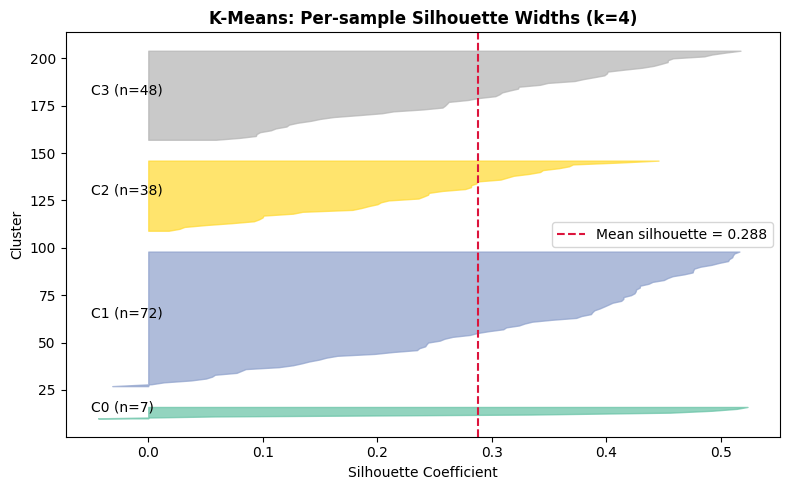

Mean silhouette by cluster:
km_cluster
0    0.334
1    0.314
2    0.226
3    0.290
Name: silhouette, dtype: float64


In [6]:
# Calculate silhouette scores to see which countries fit perfectly in their cluster
# This helps us spot borderline cases since K-Means doesn't give a confidence percentage
# Plot the scores for each cluster and draw a line at the overall average score
# Save the plot as a image file and display the breakdown by cluster
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_pca, km_labels)
df_results_km["silhouette"] = sil_vals

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.Set2(np.linspace(0, 1, K))

for k in range(K):
    cluster_sil = np.sort(sil_vals[km_labels == k])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[k], edgecolor=colors[k], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f"C{k} (n={size})")
    y_lower = y_upper + 10

ax.axvline(x=sil_vals.mean(), color="crimson", linestyle="--",
           label=f"Mean silhouette = {sil_vals.mean():.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("K-Means: Per-sample Silhouette Widths (k=4)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("processed/kmeans_silhouette_plot.png", dpi=300)
plt.show()

print(f"Mean silhouette by cluster:")
print(df_results_km.groupby("km_cluster")["silhouette"].mean().round(3))

In [8]:
# Loop through the unique cluster IDs and print every country in them
for cluster in sorted(df_results_km["km_cluster"].unique()):
    subset = df_results_km[df_results_km["km_cluster"] == cluster]
    
    print(f"\nCluster {cluster} (Total: {len(subset)})")
    # Sort alphabetically by country name for readability
    print(subset[["country", "region", "wb_econ"]].sort_values("country").to_string(index=False))


Cluster 0 (Total: 7)
         country              region  wb_econ
          Bhutan          South Asia      2.0
        Botswana  Sub-Saharan Africa      2.0
         Burundi  Sub-Saharan Africa      1.0
Papua New Guinea East Asia & Pacific      2.0
 Solomon Islands East Asia & Pacific      2.0
    South Africa  Sub-Saharan Africa      2.0
         Vanuatu East Asia & Pacific      2.0

Cluster 1 (Total: 72)
                 country                     region  wb_econ
                 Albania      Europe & Central Asia      2.0
               Argentina                   Americas      2.0
                 Armenia      Europe & Central Asia      2.0
               Australia        East Asia & Pacific      4.0
                 Austria      Europe & Central Asia      4.0
              Azerbaijan      Europe & Central Asia      2.0
                 Bahamas                   Americas      4.0
                 Bahrain Middle East & North Africa      4.0
                 Belarus      Europe &

In [9]:
km_archetype_labels = {
    "0": "Critical legislative gaps (Small states & South Africa exception)",
    "1": "High income & developed economies (Formal equality guarantees)",
    "2": "Developing economies with high gender labor exclusion",
    "3": "Low & lower-middle income (Baseline gender inclusion)"
}

# Apply the new archetype names to our results
df_results_km["archetype"] = df_results_km["km_cluster"].astype(str).map(km_archetype_labels)

In [10]:
brics = ["Brazil", "Russian Federation", "India", "China", "South Africa"]
g7    = ["Canada", "France", "Germany", "Italy", "Japan", "United Kingdom",
         "United States of America"]

df_lookup_km = df_results_km[["country", "region", "wb_econ", "km_cluster",
                               "archetype", "silhouette"]].copy()

for group_name, members in [("BRICS", brics), ("G7", g7)]:
    print(f"\n--- {group_name} ---")
    result = df_lookup_km[df_lookup_km["country"].isin(members)].sort_values("km_cluster")
    missing = [c for c in members if c not in df_lookup_km["country"].values]
    print(result.to_string(index=False))
    if missing:
        print(f"  Not in dataset: {missing}")
    print("-" * 75)


--- BRICS ---
           country                region  wb_econ km_cluster                                                         archetype  silhouette
      South Africa    Sub-Saharan Africa      2.0          0 Critical legislative gaps (Small states & South Africa exception)   -0.043812
            Brazil              Americas      2.0          1    High income & developed economies (Formal equality guarantees)    0.429636
             China   East Asia & Pacific      2.0          1    High income & developed economies (Formal equality guarantees)    0.328604
Russian Federation Europe & Central Asia      4.0          1    High income & developed economies (Formal equality guarantees)    0.429346
             India            South Asia      2.0          2             Developing economies with high gender labor exclusion    0.286766
---------------------------------------------------------------------------

--- G7 ---
                 country                region  wb_econ km_clus

In [11]:
# Load the GMM labels and merge them with our K-Means results using the ISO codes
# Calculate the Adjusted Rand Index to see how well the two clusterings match up
# An ARI of 1 means they match perfectly, while 0 means they only match by pure chance
# Create and print a cross-tabulation table to see exactly where the assignments differ
from sklearn.metrics import adjusted_rand_score

df_gmm = pd.read_csv("processed/gmm_clusters.csv")[["iso3", "gmm_cluster"]]
df_compare = df_results_km[["iso3", "km_cluster"]].merge(df_gmm, on="iso3")

ari = adjusted_rand_score(df_compare["gmm_cluster"].astype(int),
                          df_compare["km_cluster"].astype(int))

print(f"Adjusted Rand Index (GMM vs K-Means): {ari:.4f}")
print()

ct = pd.crosstab(df_compare["gmm_cluster"], df_compare["km_cluster"],
                 rownames=["GMM"], colnames=["K-Means"])
print("Cross-tabulation (GMM rows × K-Means columns):")
print(ct)

Adjusted Rand Index (GMM vs K-Means): 0.1891

Cross-tabulation (GMM rows × K-Means columns):
K-Means  0   1   2   3
GMM                   
0        0  34   0   0
1        0  17  23  10
2        0  21  15  38
3        7   0   0   0


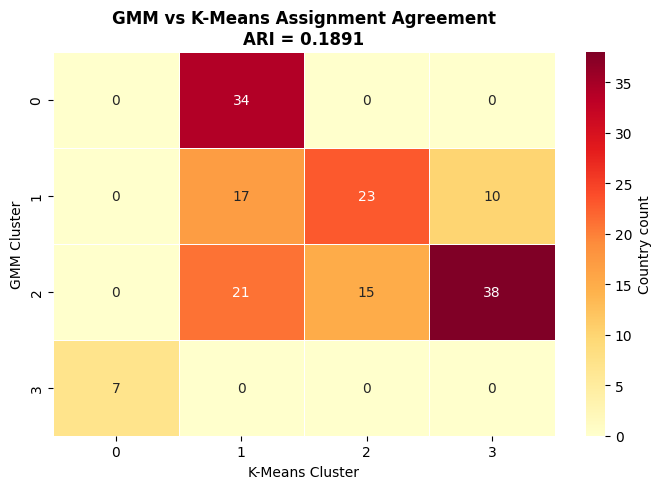

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Country count"})
ax.set_title(f"GMM vs K-Means Assignment Agreement\nARI = {ari:.4f}",
             fontweight="bold")
ax.set_xlabel("K-Means Cluster")
ax.set_ylabel("GMM Cluster")
plt.tight_layout()
plt.savefig("processed/kmeans_gmm_crosstab.png", dpi=300)
plt.show()

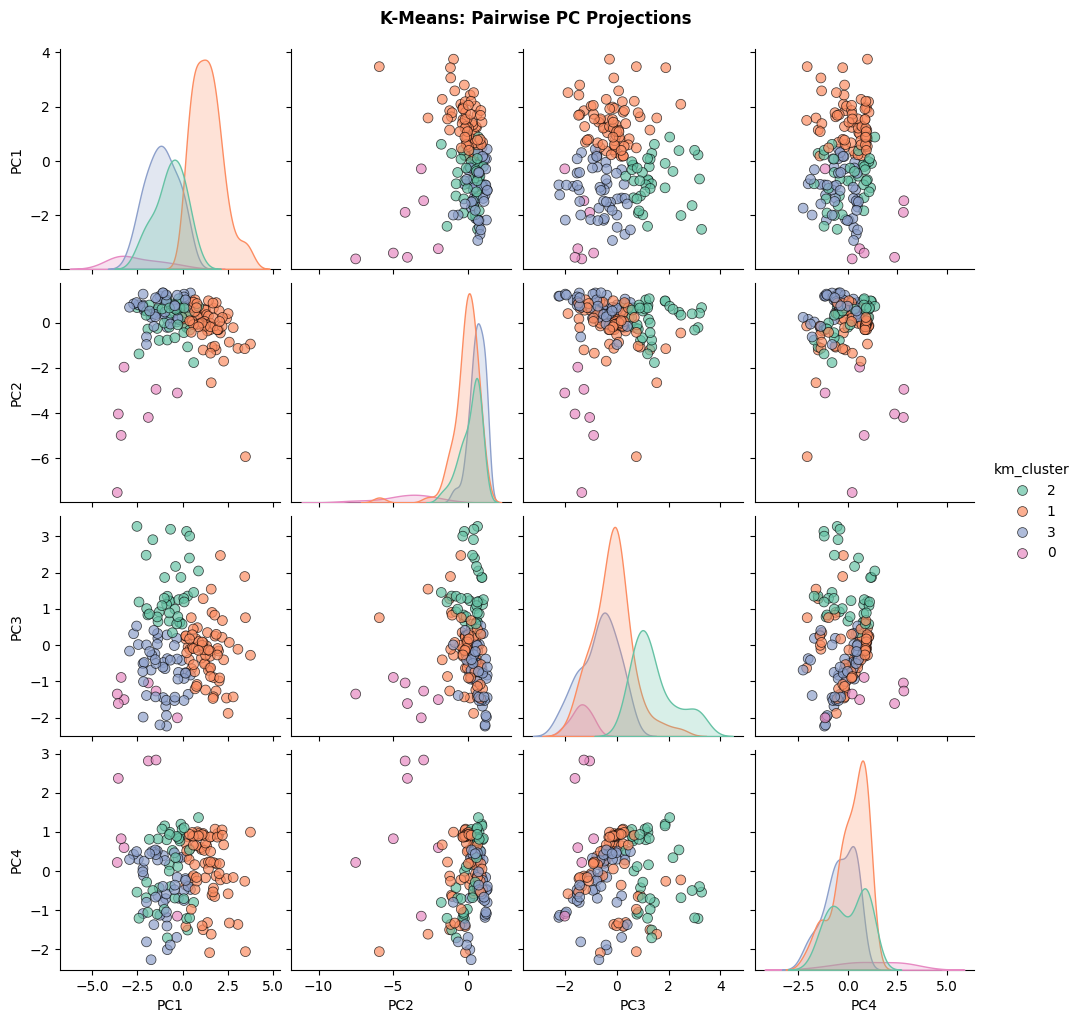

In [13]:
g = sns.pairplot(
    df_results_km, vars=["PC1", "PC2", "PC3", "PC4"],
    hue="km_cluster", palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.7, "edgecolor": "k", "s": 50}
)
g.fig.suptitle("K-Means: Pairwise PC Projections", y=1.02, fontweight="bold")
plt.savefig("processed/kmeans_pairwise.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
df_results_km.to_csv("processed/kmeans_clusters.csv", index=False)
print("Saved: processed/kmeans_clusters.csv")
print(f"Shape: {df_results_km.shape}")
print(f"Columns: {df_results_km.columns.tolist()}")

Saved: processed/kmeans_clusters.csv
Shape: (165, 11)
Columns: ['iso3', 'country', 'region', 'wb_econ', 'PC1', 'PC2', 'PC3', 'PC4', 'km_cluster', 'silhouette', 'archetype']
